In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [10]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [11]:
# check for duplicated rows
df.duplicated().sum()


np.int64(0)

In [13]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   int64         
 5   Vote_Average       9827 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9827 non-null   object        
 8   Poster_Url         9827 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 691.1+ KB


In [14]:
df['Release_Year'] = df['Release_Date'].dt.year
display(df.head())

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021


In [15]:
df = df.drop(columns=['Overview', 'Original_Language', 'Poster_Url'])
display(df.head())

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller,2022
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021


In [17]:
# Define bins and labels for categorization
bins = [0, 5, 6.5, 7.5, 10]
labels = ['Not Popular', 'Below Average', 'Average', 'Popular']

# Create the 'Vote_Category' column
df['Vote_Category'] = pd.cut(df['Vote_Average'], bins=bins, labels=labels, right=True)

print(df['Vote_Average'].describe())

display(df.head())
display(df['Vote_Category'].value_counts())

count    9827.000000
mean        6.439534
std         1.129759
min         0.000000
25%         5.900000
50%         6.500000
75%         7.100000
max        10.000000
Name: Vote_Average, dtype: float64


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year,Vote_Category
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021,Popular
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022,Popular
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller,2022,Below Average
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021,Popular
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021,Average


,count
Vote_Category,
Below Average,4273
Average,3706
Popular,1156
Not Popular,592


• Exploration Summary

• we have a dataframe consisting of 9827 rows and 9 columns.
• our dataset looks a bit tidy with no NaNs nor duplicated values.
• Release_Date column needs to be casted into date time and to extract only the
• Overview, Original_Languege and Poster-Url wouldn't be so useful during analys
• there is noticable outliers in Popularity column
• Vote_Average bettter be categorised for proper analysis.
• Genre column has comma saperated values and white spaces that needs to be hand

In [18]:
# dropping NaNs
df.dropna(inplace = True)
# confirming
df.isna().sum()


,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0
Release_Year,0
Vote_Category,0


In [19]:
# Clean and split the 'Genre' column
df['Genre'] = df['Genre'].apply(lambda x: [g.strip() for g in x.split(',')])

# Explode the DataFrame to have one genre per row
df_genres = df.explode('Genre')

display(df_genres.head())
print(f"Number of unique genres: {df_genres['Genre'].nunique()}")
display(df_genres['Genre'].value_counts().head(10))

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year,Vote_Category
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,Action,2021,Popular
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,2021,Popular
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,2021,Popular
1,2022-03-01,The Batman,3827.658,1151,8.1,Crime,2022,Popular
1,2022-03-01,The Batman,3827.658,1151,8.1,Mystery,2022,Popular


Number of unique genres: 19


,count
Genre,
Drama,3715
Comedy,3006
Action,2652
Thriller,2473
Adventure,1829
Romance,1461
Horror,1457
Animation,1426
Family,1405


### Genre Distribution
Let's visualize the distribution of genres to see which ones are most common in our dataset.

/tmp/ipykernel_638/1136509436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


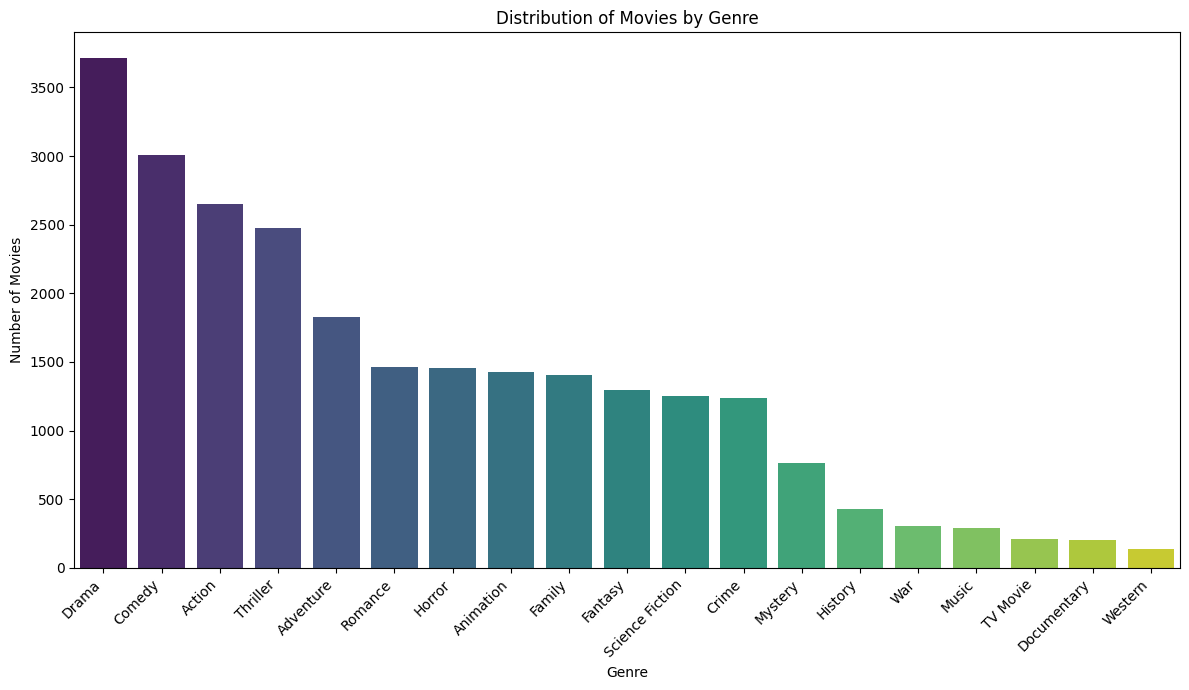

In [20]:
# Calculate the count of each genre
genre_counts = df_genres['Genre'].value_counts()

# Create a bar plot of genre counts
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Distribution of Movies by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Average Vote_Average by Genre
Let's analyze which genres receive the highest average ratings.

/tmp/ipykernel_638/2021163412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_vote_by_genre.index, y=average_vote_by_genre.values, palette='coolwarm')


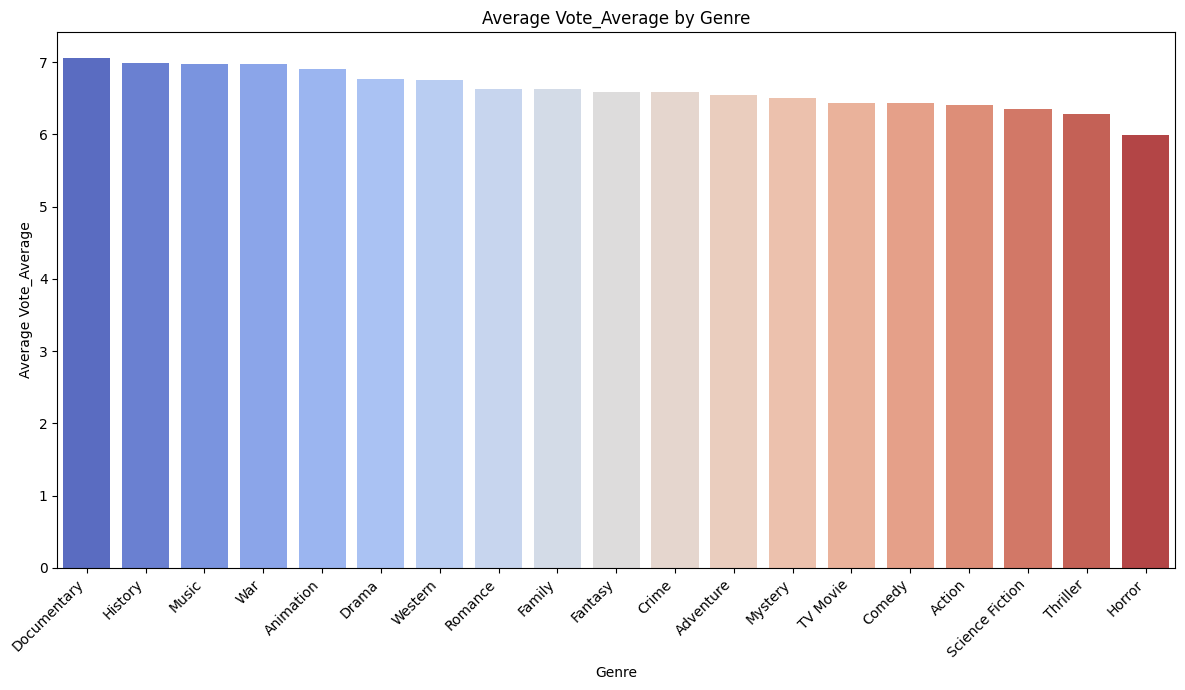

In [21]:
# Calculate the average Vote_Average for each genre
average_vote_by_genre = df_genres.groupby('Genre')['Vote_Average'].mean().sort_values(ascending=False)

# Create a bar plot of average vote by genre
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=average_vote_by_genre.index, y=average_vote_by_genre.values, palette='coolwarm')
plt.title('Average Vote_Average by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Vote_Average')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Vote Category Distribution by Genre
Let's analyze the distribution of `Vote_Category` for each genre to identify which genres have a higher proportion of highly-rated movies.

/tmp/ipykernel_638/4085153329.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_vote_category_counts = df_genres.groupby(['Genre', 'Vote_Category']).size().unstack(fill_value=0)


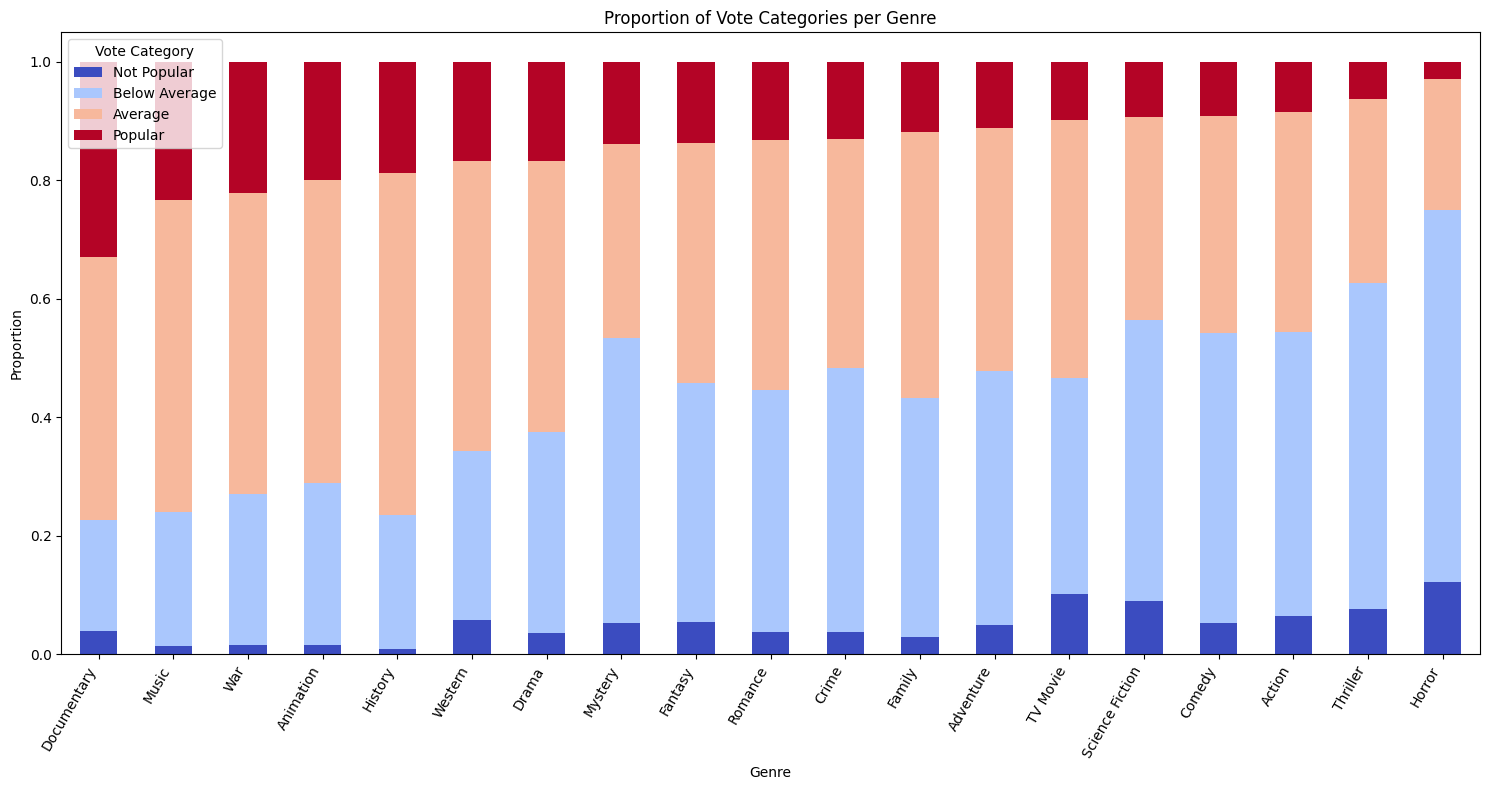

In [22]:
# Calculate the count of each Vote_Category within each Genre
genre_vote_category_counts = df_genres.groupby(['Genre', 'Vote_Category']).size().unstack(fill_value=0)

# Normalize the counts to get proportions within each genre
genre_vote_category_proportions = genre_vote_category_counts.apply(lambda x: x / x.sum(), axis=1)

# Sort by the 'Popular' category to highlight top genres by high ratings
genre_vote_category_proportions = genre_vote_category_proportions.sort_values(by='Popular', ascending=False)

# Create a stacked bar chart
fig = plt.figure(figsize=(15, 8))
genre_vote_category_proportions.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='coolwarm', ax=plt.gca())
plt.title('Proportion of Vote Categories per Genre')
plt.xlabel('Genre')
plt.ylabel('Proportion')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Vote Category')
plt.tight_layout()
plt.show()

### Q3: Movie with Highest Popularity
Let's find the movie with the highest popularity and its genre(s).

In [23]:
# Find the movie with the highest popularity
highest_popularity_movie = df.loc[df['Popularity'].idxmax()]

print("Movie with the Highest Popularity:")
print(f"Title: {highest_popularity_movie['Title']}")
print(f"Popularity: {highest_popularity_movie['Popularity']}")
print(f"Genre(s): {', '.join(highest_popularity_movie['Genre'])}")

Movie with the Highest Popularity:
Title: Spider-Man: No Way Home
Popularity: 5083.954
Genre(s): Action, Adventure, Science Fiction


### Q4: Movie with Lowest Popularity
Now, let's find the movie with the lowest popularity and its genre(s).

In [24]:
# Find the movie with the lowest popularity
lowest_popularity_movie = df.loc[df['Popularity'].idxmin()]

print("Movie with the Lowest Popularity:")
print(f"Title: {lowest_popularity_movie['Title']}")
print(f"Popularity: {lowest_popularity_movie['Popularity']}")
print(f"Genre(s): {', '.join(lowest_popularity_movie['Genre'])}")

Movie with the Lowest Popularity:
Title: The United States vs. Billie Holiday
Popularity: 13.354
Genre(s): Music, Drama, History


### Q5: Year with the Most Filmed Movies
Let's determine which `Release_Year` has the highest number of movie releases.

In [25]:
# Calculate the number of movies per year
movies_per_year = df['Release_Year'].value_counts().sort_values(ascending=False)

# Get the year with the most movies
year_most_movies = movies_per_year.index[0]
count_most_movies = movies_per_year.iloc[0]

print(f"The year with the most filmed movies is {year_most_movies} with {count_most_movies} releases.")

# Optionally, display the top 5 years for context
print("\nTop 5 years with the most movie releases:")
display(movies_per_year.head())

The year with the most filmed movies is 2021 with 712 releases.

Top 5 years with the most movie releases:


,count
Release_Year,
2021,712
2018,528
2017,510
2019,499
2016,469
